In [1]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
from math import factorial
import matplotlib.pyplot as plt

In [2]:
def bs_call(s, k, T, vol, r, q, t=0):
    tao = T-t
    d1 = (np.log(s/k)+(r-q+0.5*vol**2)*tao)/(vol*np.sqrt(tao))
    d2 = d1-vol*np.sqrt(tao)

    C = s*np.exp(-q*tao)*norm.cdf(d1) - k*np.exp(-r*tao)*norm.cdf(d2)
    return C

def p_NT_is_n(T, lamb, n, t=0):
    tao = T-t
    return np.exp(-lamb*tao)*(lamb*tao)**n/factorial(n)

def jump_call_solution(s, k, T, vol, r, q, lamb, gamma, t=0):
    adjusted_q = q+lamb*gamma
    j = 0
    proba = p_NT_is_n(T, lamb, j)
    C = 0
    while proba > 1e-12:
        adjusted_s = s*(1+gamma)**j
        C += proba*bs_call(adjusted_s, k, T, vol, r, adjusted_q)
        j += 1
        proba = p_NT_is_n(T, lamb, j)
    return C


In [3]:
GAMMA = -0.08 # the convention in the course and formulas are gamma positive
LAMBDA_Q = 0.2
VOL = 0.2
R = 0.04
Q = 0 # non-dividend-paying stock
T_list = [0.02, 0.08, 0.25, 0.5]
S = 100
K_list = [round(i*S, 1) for i in [0.8, 0.9, 1.0, 1.1]]

jump_call_value_dic = {(K,T): jump_call_solution(S, K, T, VOL, R, Q, LAMBDA_Q, GAMMA) for K in K_list for T in T_list}
for key, value in jump_call_value_dic.items():
    k, t = key
    print(f'The call value for the jump model using strike: {k:.1f} and time to maturity: {t:.1f} is {value:.3f}')


The call value for the jump model using strike: 80.0 and time to maturity: 0.0 is 20.064
The call value for the jump model using strike: 80.0 and time to maturity: 0.1 is 20.256
The call value for the jump model using strike: 80.0 and time to maturity: 0.2 is 20.834
The call value for the jump model using strike: 80.0 and time to maturity: 0.5 is 21.829
The call value for the jump model using strike: 90.0 and time to maturity: 0.0 is 10.073
The call value for the jump model using strike: 90.0 and time to maturity: 0.1 is 10.357
The call value for the jump model using strike: 90.0 and time to maturity: 0.2 is 11.519
The call value for the jump model using strike: 90.0 and time to maturity: 0.5 is 13.216
The call value for the jump model using strike: 100.0 and time to maturity: 0.0 is 1.180
The call value for the jump model using strike: 100.0 and time to maturity: 0.1 is 2.449
The call value for the jump model using strike: 100.0 and time to maturity: 0.2 is 4.549
The call value for th

In [4]:
def implied_vol_call(price, s, k, T, r, q=0, t=0):
    def objective(vol):
        return bs_call(s, k, T, vol, r, q, t) - price
    return brentq(objective, 1e-6, 5.0)

implied_vols = {}
for T in T_list:
    for K in K_list:
        price = jump_call_value_dic[(K, T)]
        iv = implied_vol_call(price, S, K, T, R, Q)
        implied_vols[(K, T)] = iv

for (K, T), iv in implied_vols.items():
    print(f"K/S={K/S:.1f}, T={T:.2f}, Implied vol={iv:.4%}")

K/S=0.8, T=0.02, Implied vol=31.4027%
K/S=0.9, T=0.02, Implied vol=25.0377%
K/S=1.0, T=0.02, Implied vol=20.2110%
K/S=1.1, T=0.02, Implied vol=20.0574%
K/S=0.8, T=0.08, Implied vol=22.1457%
K/S=0.9, T=0.08, Implied vol=20.7434%
K/S=1.0, T=0.08, Implied vol=20.2905%
K/S=1.1, T=0.08, Implied vol=20.1593%
K/S=0.8, T=0.25, Implied vol=20.6156%
K/S=0.9, T=0.25, Implied vol=20.4307%
K/S=1.0, T=0.25, Implied vol=20.3221%
K/S=1.1, T=0.25, Implied vol=20.2547%
K/S=0.8, T=0.50, Implied vol=20.4524%
K/S=0.9, T=0.50, Implied vol=20.3818%
K/S=1.0, T=0.50, Implied vol=20.3307%
K/S=1.1, T=0.50, Implied vol=20.2924%


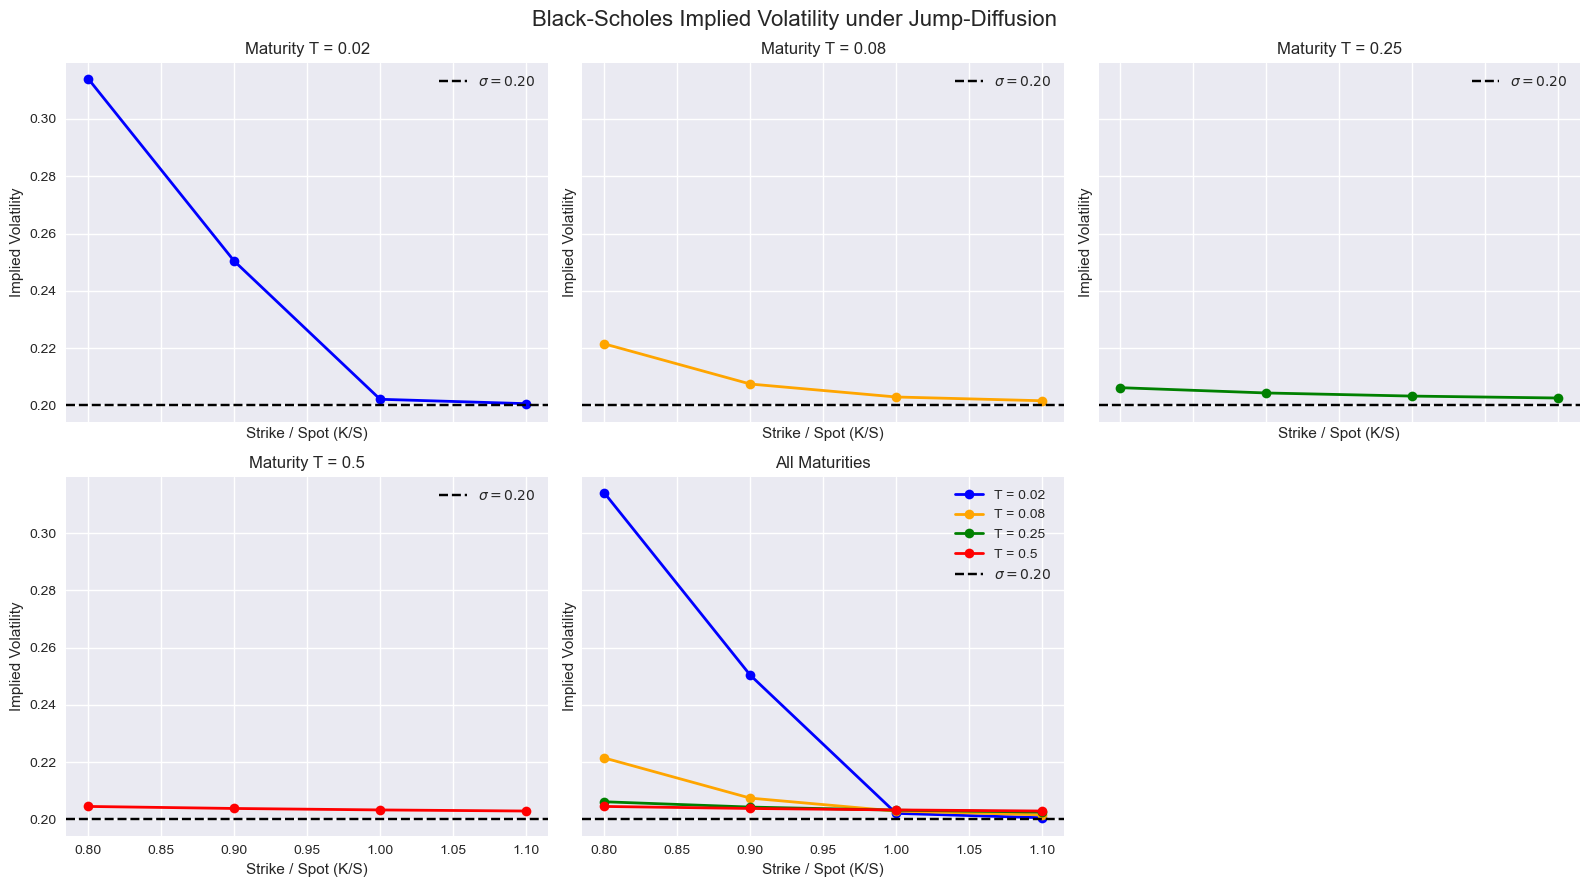

In [5]:
plt.style.use('seaborn-v0_8')

moneyness = [K / S for K in K_list]
colors = ['blue', 'orange', 'green', 'red']
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()

for i, (T, color) in enumerate(zip(T_list, colors)):
    vols = [implied_vols[(K, T)] for K in K_list]
    axes[i].plot(moneyness,vols,marker='o',linewidth=2,color=color)
    axes[i].axhline(VOL,linestyle='--',color='black',label=r'$\sigma = 0.20$')
    axes[i].set_title(f'Maturity T = {T}')
    axes[i].set_xlabel('Strike / Spot (K/S)')
    axes[i].set_ylabel('Implied Volatility')
    axes[i].grid(True)
    axes[i].legend()

for T, color in zip(T_list, colors):
    vols = [implied_vols[(K, T)] for K in K_list]
    axes[4].plot(moneyness,vols,marker='o',linewidth=2,color=color,label=f'T = {T}')
axes[4].axhline(VOL,linestyle='--',color='black',label=r'$\sigma = 0.20$')
axes[4].set_title('All Maturities')
axes[4].set_xlabel('Strike / Spot (K/S)')
axes[4].set_ylabel('Implied Volatility')
axes[4].grid(True)
axes[4].legend()

fig.delaxes(axes[5])
fig.suptitle('Black-Scholes Implied Volatility under Jump-Diffusion',fontsize=16)
plt.tight_layout()
plt.show()